In [1]:
# CELL 0: ENVIRONMENT SETUP & VISUAL CONFIGURATION

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Plot aesthetic configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("Statistical toolkit loaded successfully!")

NumPy Version: 2.1.3
Pandas Version: 2.2.3
Statistical toolkit loaded successfully!


# SECTION 1: POPULATION VS SAMPLE & BESSEL'S CORRECTION

Concept Summary:
 - POPULATION: The entire group of interest (Size: N). Parameters: μ (mean), σ² (variance).
 - SAMPLE: A representative subset drawn from the population (Size: n). Statistics: x̄ (mean), s² (variance).

Bessel's Correction (Why divide sample variance by n - 1?):
- Using sample mean x̄ instead of true population mean μ systematically underestimates spread because sample data points are closer to x̄ than to μ. Dividing by (n - 1) removes this bias, making s² an UNBIASED estimator of σ².

In [2]:
np.random.seed(42)
true_population = np.random.normal(loc=100.0, scale=15.0, size=1_000_000)

# Extract a small sample
sample_n = 30
sample_data = np.random.choice(true_population, size=sample_n, replace=False)

print(f"Population Mean (μ):    {np.mean(true_population):.4f}  | Parameter")
print(f"Sample Mean (x̄):        {np.mean(sample_data):.4f}  | Statistic (Estimator)")
print(f"\nBiased Sample Std (N):  {np.std(sample_data, ddof=0):.4f}  (Underestimates true σ)")
print(f"Unbiased Sample Std(N-1): {np.std(sample_data, ddof=1):.4f}  (Bessel corrected -> matches σ={15.0})")

Population Mean (μ):    99.9760  | Parameter
Sample Mean (x̄):        96.6830  | Statistic (Estimator)

Biased Sample Std (N):  17.7833  (Underestimates true σ)
Unbiased Sample Std(N-1): 18.0873  (Bessel corrected -> matches σ=15.0)


### SECTION 2: CENTRAL TENDENCY & WORKED SALARY EXAMPLE

 Measures:
 - MEAN (Arithmetic Average): Sensitive to all values; pulled heavily by extreme outliers.
 - MEDIAN (50th Percentile): Positional midpoint; robust to skewness and outliers.
 - MODE: Most frequently occurring value; best for discrete/categorical data.

In [3]:
# WORKED EXAMPLE: 9 software engineers and 1 executive
salaries = np.array([55_000, 58_000, 60_000, 62_000, 65_000, 68_000, 70_000, 72_000, 75_000, 1_500_000])

mean_sal = np.mean(salaries)
median_sal = np.median(salaries)
mode_sal = stats.mode(salaries, keepdims=True).mode[0]

print("=== Tech Startup Salary Distribution ===")
print(f"Individual Salaries: {salaries}")
print(f"Mean Salary:   ${mean_sal:,.2f}  <-- Heavily distorted by the $1.5M executive")
print(f"Median Salary: ${median_sal:,.2f}  <-- Represents the typical employee experience")
print(f"Mode Salary:   ${mode_sal:,.2f}")
print("\nAnalytical Takeaway: When data is skewed or has outliers, report the MEDIAN.")

=== Tech Startup Salary Distribution ===
Individual Salaries: [  55000   58000   60000   62000   65000   68000   70000   72000   75000
 1500000]
Mean Salary:   $208,500.00  <-- Heavily distorted by the $1.5M executive
Median Salary: $66,500.00  <-- Represents the typical employee experience
Mode Salary:   $55,000.00

Analytical Takeaway: When data is skewed or has outliers, report the MEDIAN.


### SECTION 3: MEASURES OF DISPERSION & WHY WE SQUARE DEVIATIONS

1. Range: Max - Min (crude, highly sensitive to extremes)
2. Variance (s²): Average squared deviation from the mean
3. Standard Deviation (s): Square root of variance; returned to original feature units
4. Coefficient of Variation (CV): (s / μ) * 100% -> Unitless relative dispersion

WHY SQUARE DEVIATIONS INSTEAD OF SUMMING RAW DIFFERENCES?  
A. **The Zero-Sum Cancellation:** `Σ(x - μ)` is ALWAYS identically 0 because negative and
positive errors cancel out.  
B. **Non-Linear Penalty:** Squaring penalises large errors progressively more than small ones.  
C. **Differentiability:** Absolute values `|x - μ|` have a sharp cusp at zero (non-differentiable), making squared math smoother for calculus and gradient optimization.

In [12]:
data_disp = np.array([10, 12, 14, 16, 18, 20])
diffs = data_disp - np.mean(data_disp)

print(f"Values: {data_disp}")
print(f"Deviations from mean ({np.mean(data_disp)}): {diffs}")
print(f"Sum of raw deviations: {np.sum(diffs):.2f} (Cancels to 0!)")
print(f"Sum of squared deviations: {np.sum(diffs**2):.2f}")
print(f"Sample Std Dev (s): {np.std(data_disp, ddof=1):.2f}")
print(f"Coefficient of Variation (CV): {(np.std(data_disp, ddof=1) / np.mean(data_disp)) * 100:.2f}%")

Values: [10 12 14 16 18 20]
Deviations from mean (15.0): [-5. -3. -1.  1.  3.  5.]
Sum of raw deviations: 0.00 (Cancels to 0!)
Sum of squared deviations: 70.00
Sample Std Dev (s): 3.74
Coefficient of Variation (CV): 24.94%


### SECTION 4: POSITION METRICS, FIVE-NUMBER SUMMARY & BOX PLOT ANATOMY

- The Five-Number Summary: [Min, Q1 (25%), Q2/Median (50%), Q3 (75%), Max]
- Interquartile Range (IQR) = Q3 - Q1 (Middle 50% of data)

--- Five-Number Summary & Fences ---
Min: 2 | Q1: 6.25 | Median: 8.5 | Q3: 11.75 | Max: 28
IQR: 5.50 | Lower Fence: -2.00 | Upper Fence: 20.00
Whiskers: [2, 15]


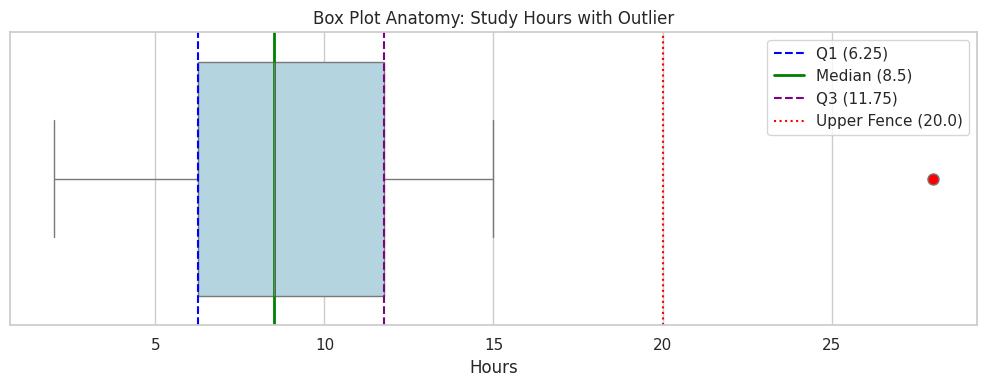

In [13]:
study_hours = np.array([2, 4, 5, 6, 7, 8, 8, 9, 10, 11, 12, 14, 15, 28]) # 28 is an outlier

q1 = np.percentile(study_hours, 25)
median_q2 = np.percentile(study_hours, 50)
q3 = np.percentile(study_hours, 75)
iqr = q3 - q1

# Tukey Fences
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Whiskers extend to the lowest and highest non-outlier data points within fences
whisker_low = study_hours[study_hours >= lower_fence].min()
whisker_high = study_hours[study_hours <= upper_fence].max()

print("--- Five-Number Summary & Fences ---")
print(f"Min: {study_hours.min()} | Q1: {q1} | Median: {median_q2} | Q3: {q3} | Max: {study_hours.max()}")
print(f"IQR: {iqr:.2f} | Lower Fence: {lower_fence:.2f} | Upper Fence: {upper_fence:.2f}")
print(f"Whiskers: [{whisker_low}, {whisker_high}]")

# Visual Box Plot Anatomy
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=study_hours, color="lightblue", flierprops={"marker": "o", "markersize": 8, "markerfacecolor": "red"})
ax.axvline(q1, color='blue', linestyle='--', label=f'Q1 ({q1})')
ax.axvline(median_q2, color='green', linestyle='-', linewidth=2, label=f'Median ({median_q2})')
ax.axvline(q3, color='purple', linestyle='--', label=f'Q3 ({q3})')
ax.axvline(upper_fence, color='red', linestyle=':', label=f'Upper Fence ({upper_fence})')
ax.set_title("Box Plot Anatomy: Study Hours with Outlier")
ax.set_xlabel("Hours")
ax.legend()
plt.tight_layout()
plt.show()

### SECTION 5: SHAPE METRICS — SKEWNESS & KURTOSIS

1. **SKEWNESS (Asymmetry of the distribution):**
1.1 Negative (Left) Skew:  Tail stretches left.  Mean < Median < Mode (Skew < -0.5)
2. **Symmetric:** Tail balance equal.   Mean ≈ Median ≈ Mode (Skew ≈ 0)  
2.1 Positive (Right) Skew: Tail stretches right. Mean > Median > Mode (Skew > +0.5)

3. **KURTOSIS (Tail weight / Outlier propensity relative to normal distribution):**  
- Mesokurtic (Excess Kurtosis ≈ 0): Normal bell curve tails.  
- Leptokurtic (Excess Kurtosis > 0): Heavy tails, sharp peak, prone to extreme outliers.  
- Platykurtic (Excess Kurtosis < 0): Light tails, flat peak, low outlier frequency.

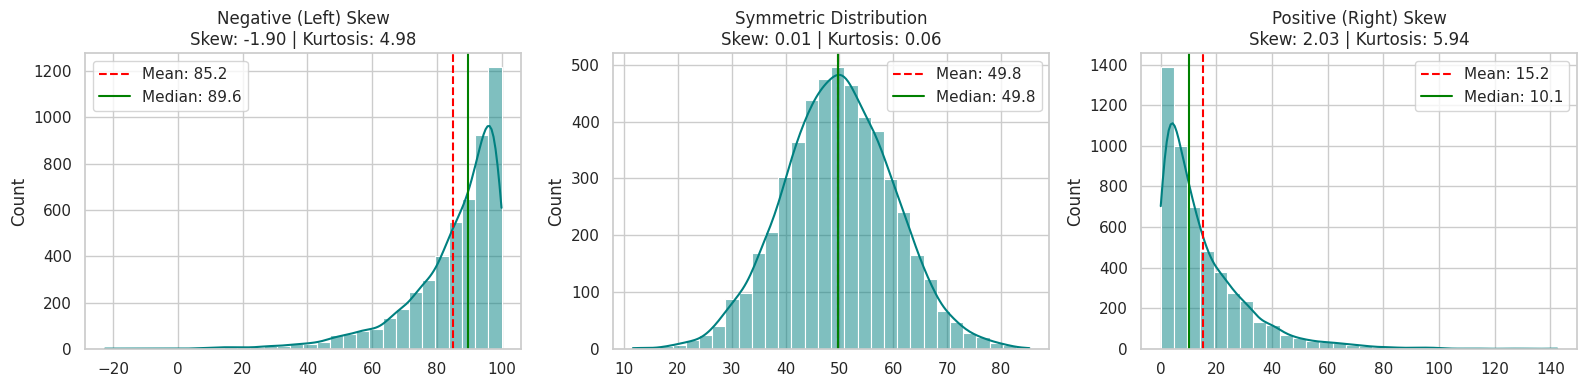

In [14]:
np.random.seed(42)
left_skew = 100 - np.random.exponential(scale=15, size=5000)   # Left/Negatively skewed
sym_dist  = np.random.normal(loc=50, scale=10, size=5000)        # Symmetric
right_skew = np.random.exponential(scale=15, size=5000)          # Right/Positively skewed

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, data, name in zip(axes, [left_skew, sym_dist, right_skew],
                          ["Negative (Left) Skew", "Symmetric Distribution", "Positive (Right) Skew"]):
    sns.histplot(data, kde=True, ax=ax, color='teal', bins=30)
    ax.axvline(np.mean(data), color='red', linestyle='--', label=f"Mean: {np.mean(data):.1f}")
    ax.axvline(np.median(data), color='green', linestyle='-', label=f"Median: {np.median(data):.1f}")
    ax.set_title(f"{name}\nSkew: {stats.skew(data):.2f} | Kurtosis: {stats.kurtosis(data):.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

### SECTION 6: OUTLIER VS ANOMALY VS ERROR & DETECTION METHODS

Taxonomy:
1. DATA ERROR: Invalid measurement/typo (e.g., Human Age = 250, temperature = -500°C). Fix: Correct or drop.
2. ANOMALY: Statistically rare event signaling a systemic change or fraud. Fix: Flag for investigation.
3. OUTLIER: Legitimate natural extreme value in a heavy-tailed process. Fix: Capping/Winsorization.

In [7]:
data_points = np.array([22, 24, 25, 25, 26, 27, 28, 29, 30, 31, 32, 95]) # 95 is extreme

# Method 1: Z-Score (|Z| > 3 flags outliers assuming normal distribution)
z_scores = np.abs((data_points - np.mean(data_points)) / np.std(data_points, ddof=1))
z_outliers = data_points[z_scores > 2.5] # using 2.5 for small sample demonstration

# Method 2: 1.5x IQR Rule (Non-parametric; robust against non-normal skew)
q1_d, q3_d = np.percentile(data_points, [25, 75])
iqr_d = q3_d - q1_d
iqr_outliers = data_points[(data_points < (q1_d - 1.5 * iqr_d)) | (data_points > (q3_d + 1.5 * iqr_d))]

print(f"Data: {data_points}")
print(f"Z-Score Outliers: {z_outliers}")
print(f"IQR Outliers:     {iqr_outliers}")

Data: [22 24 25 25 26 27 28 29 30 31 32 95]
Z-Score Outliers: [95]
IQR Outliers:     [95]


### SECTION 7: COVARIANCE, CORRELATION & SPURIOUS CORRELATION

- Covariance: Direction of linear relationship (scale-dependent, unstandardised).
- Pearson Correlation (r): Standardised linear strength in [-1.0, 1.0].
- Spearman Correlation (ρ): Rank-based; measures MONOTONIC relationships (handles non-linear curves & outliers).

=== Spurious Correlation Analysis ===
Pearson Correlation between Ice Cream Sales & Drownings: r = 0.863 (p < 0.001)
INTERPRETATION: Highly correlated! Does ice cream cause drowning? NO.
The lurking confounding variable is TEMPERATURE (hot weather causes both).


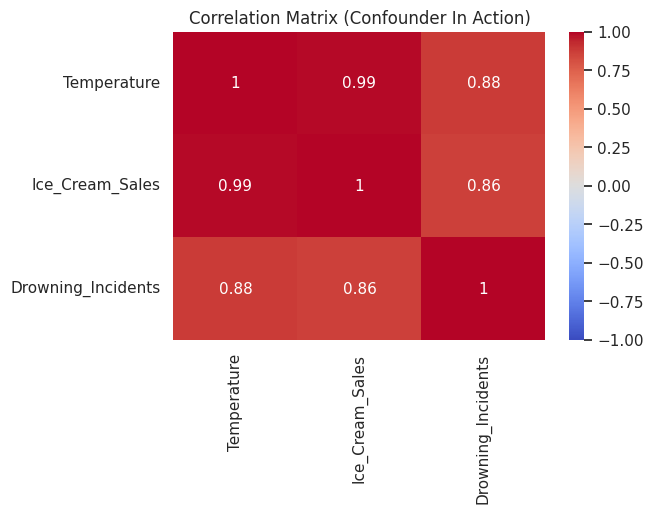

In [8]:
# SPUROUS CORRELATION DEMONSTRATION:
# Confounder: Daily Summer Temperature drives BOTH Ice Cream Sales and Drowning Incidents.
np.random.seed(42)
temp = np.random.uniform(20, 38, 100) # Temperature in Celsius
ice_cream_sales = temp * 50 + np.random.normal(0, 50, 100)
drowning_incidents = temp * 1.5 + np.random.normal(0, 4, 100)

spurious_df = pd.DataFrame({
    'Temperature': temp,
    'Ice_Cream_Sales': ice_cream_sales,
    'Drowning_Incidents': drowning_incidents
})

r, p_val = stats.pearsonr(spurious_df['Ice_Cream_Sales'], spurious_df['Drowning_Incidents'])
print("=== Spurious Correlation Analysis ===")
print(f"Pearson Correlation between Ice Cream Sales & Drownings: r = {r:.3f} (p < 0.001)")
print("INTERPRETATION: Highly correlated! Does ice cream cause drowning? NO.")
print("The lurking confounding variable is TEMPERATURE (hot weather causes both).")

# Visual Correlation Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(spurious_df.corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Confounder In Action)")
plt.show()

### SECTION 8: LIVE CODE DEMO — MANUAL STATISTICAL SUMMARY VS DF.DESCRIBE()

In [15]:
# We will generate a dataset, build a manual statistical profile with pure NumPy,
# and verify it down to the decimal point against pd.DataFrame.describe().

np.random.seed(101)
raw_test_data = np.random.lognormal(mean=3.0, sigma=0.75, size=250)
test_series = pd.Series(raw_test_data, name="Revenue_USD")

def manual_describe(arr: np.ndarray) -> dict:
    """Computes full parametric and non-parametric summary statistics manually."""
    n = len(arr)
    mean_val = np.sum(arr) / n
    # Sample variance with Bessel's correction (ddof=1)
    variance_val = np.sum((arr - mean_val) ** 2) / (n - 1)
    std_val = np.sqrt(variance_val)

    sorted_arr = np.sort(arr)
    min_val = sorted_arr[0]
    max_val = sorted_arr[-1]

    # Percentiles matching Pandas linear interpolation standard
    p25 = np.percentile(sorted_arr, 25)
    p50 = np.percentile(sorted_arr, 50)
    p75 = np.percentile(sorted_arr, 75)

    # Higher order moments
    skew_val = stats.skew(arr)
    kurt_val = stats.kurtosis(arr) # Excess kurtosis

    return {
        'count': float(n),
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        '25%': p25,
        '50%': p50,
        '75%': p75,
        'max': max_val,
        'skewness': skew_val,
        'kurtosis': kurt_val
    }

# 1. Manual Profile
manual_stats = manual_describe(raw_test_data)
manual_df = pd.DataFrame(list(manual_stats.items()), columns=['Metric', 'Manual_NumPy']).set_index('Metric')

# 2. Pandas Native Describe
pandas_stats = test_series.describe()
pandas_stats.loc['skewness'] = test_series.skew()
pandas_stats.loc['kurtosis'] = test_series.kurt()
manual_df['Pandas_Native'] = pandas_stats

print("=== VERIFICATION: MANUAL NUMPY VS PANDAS DESCRIBE() ===")
display(manual_df.round(4))

# Formal programmatic assertion
for metric in ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']:
    assert np.isclose(manual_df.loc[metric, 'Manual_NumPy'], manual_df.loc[metric, 'Pandas_Native']), f"Mismatch in {metric}"
print("\n All manual calculations match `df.describe()` with precision.")

=== VERIFICATION: MANUAL NUMPY VS PANDAS DESCRIBE() ===


,Manual_NumPy,Pandas_Native
Metric,,
count,250.0000,250.0000
mean,28.2408,28.2408
std,24.7283,24.7283
min,2.5786,2.5786
25%,11.3235,11.3235
50%,22.6078,22.6078
75%,34.6476,34.6476
max,152.9540,152.9540
skewness,2.2102,2.2236



 All manual calculations match `df.describe()` with precision.


### SECTION 9: STUDENT PRACTICE LAB — STATISTICAL DIAGNOSTICS & SKEW PROFILING

STUDENT LAB INSTRUCTIONS:
You are provided with a DataFrame `market_df` containing 3 variables:
  1. `Annual_Income`: Customer reported earnings in USD.
  2. `Test_Score`: Standardized assessment score out of 100.
  3. `Product_Weight`: Packaging weight in kilograms.

YOUR TASKS:
1. For each variable, compute: Mean, Median, Std Dev, IQR, Skewness, and Count of Outliers (using 1.5x IQR).
2. Diagnose the skewness direction for all three (Left-Skewed, Symmetric, or Right-Skewed).
3. Determine which measure of central tendency (Mean vs Median) should be reported for business decisions.


In [16]:
# Generate Student Data
np.random.seed(999)
market_df = pd.DataFrame({
    'Annual_Income': np.random.exponential(scale=35_000, size=500) + 15_000,
    'Test_Score': 100 - np.random.exponential(scale=10, size=500).clip(0, 45),
    'Product_Weight': np.random.normal(loc=5.0, scale=0.5, size=500)
})

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------



--- Variable: Annual_Income ---
Mean: 50446.98
Median: 39267.91
Standard Deviation: 35954.99
IQR: 37258.04
Skewness: 2.02
Outliers (1.5x IQR): 33
Skewness Direction: Positive (Right) Skewed
Recommended Central Tendency: Median (due to right-skewness and potential outliers)


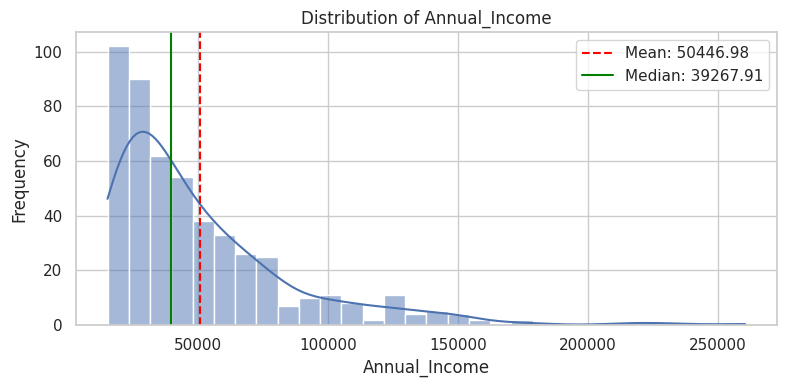


--- Variable: Test_Score ---
Mean: 90.10
Median: 92.73
Standard Deviation: 9.52
IQR: 10.89
Skewness: -1.64
Outliers (1.5x IQR): 22
Skewness Direction: Negative (Left) Skewed
Recommended Central Tendency: Median (due to left-skewness and potential outliers)


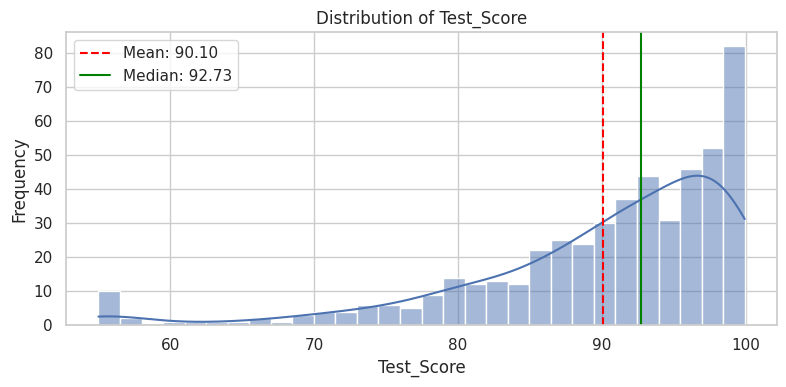


--- Variable: Product_Weight ---
Mean: 4.98
Median: 4.97
Standard Deviation: 0.54
IQR: 0.72
Skewness: -0.02
Outliers (1.5x IQR): 2
Skewness Direction: Approximately Symmetric
Recommended Central Tendency: Mean (data is relatively symmetric)


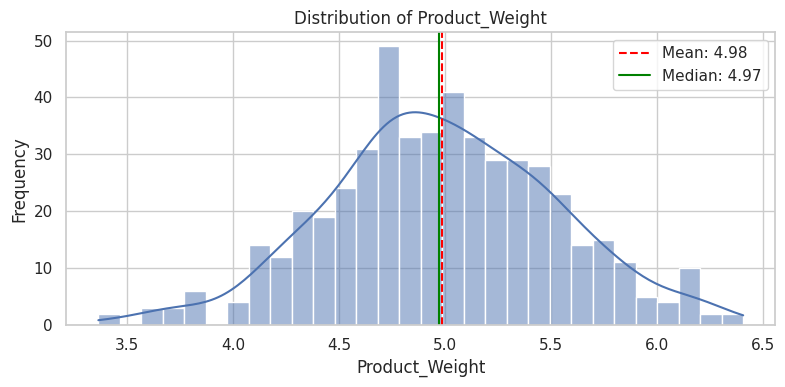

In [17]:
for col in market_df.columns:
    print(f"\n--- Variable: {col} ---")

    mean_val = market_df[col].mean()
    median_val = market_df[col].median()
    std_dev = market_df[col].std()
    skewness = market_df[col].skew()

    q1 = market_df[col].quantile(0.25)
    q3 = market_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers_count = market_df[(market_df[col] < lower_bound) | (market_df[col] > upper_bound)].shape[0]

    print(f"Mean: {mean_val:.2f}")
    print(f"Median: {median_val:.2f}")
    print(f"Standard Deviation: {std_dev:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Skewness: {skewness:.2f}")
    print(f"Outliers (1.5x IQR): {outliers_count}")

    # Diagnose skewness
    if skewness < -0.5:
        skew_direction = "Negative (Left) Skewed"
        central_tendency_recommendation = "Median (due to left-skewness and potential outliers)"
    elif skewness > 0.5:
        skew_direction = "Positive (Right) Skewed"
        central_tendency_recommendation = "Median (due to right-skewness and potential outliers)"
    else:
        skew_direction = "Approximately Symmetric"
        central_tendency_recommendation = "Mean (data is relatively symmetric)"

    print(f"Skewness Direction: {skew_direction}")
    print(f"Recommended Central Tendency: {central_tendency_recommendation}")

    # Visualize the distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(market_df[col], kde=True, bins=30)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


#**INFERENTIAL**

In [18]:
# CELL 0: ENVIRONMENT SETUP & LIBRARIES
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | SciPy: {stats.__version__ if hasattr(stats, '__version__') else 'Loaded'}")
print("Inferential Statistics Toolkit Ready!")

NumPy: 2.1.3 | Pandas: 2.2.3 | SciPy: Loaded
Inferential Statistics Toolkit Ready!


### SECTION 1: PROBABILITY, CONDITIONAL PROBABILITY & BAYES' THEOREM

- **Independent Events:** P(A ∩ B) = P(A) * P(B)  (e.g., rolling a die twice)
- **Dependent Events:**   P(A ∩ B) = P(A) * P(B | A) (e.g., drawing cards without replacement)
```
- BAYES' THEOREM:
                  P(B | A) * P(A)
-   P(A | B) = ──────────────────────
                      P(B)
```
- PRACTICAL MEDICAL TESTING EXAMPLE (The Base Rate Fallacy):
- *Disease Prevalence in population:* &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; P(D) = 1% = 0.01
- *Test Sensitivity (True Positive Rate):* &nbsp; &nbsp;P(+ | D) = 98% = 0.98
- *Test Specificity (True Negative Rate):* &nbsp;P(- | ¬D) = 90% = 0.90 -> False Positive, P(+ | ¬D) = 10% = 0.10

In [19]:
# Question: If a patient tests positive, what is the probability they actually have the disease?

p_disease = 0.01
p_no_disease = 1.0 - p_disease

p_pos_given_disease = 0.98       # Sensitivity
p_pos_given_no_disease = 0.10    # False Positive (1 - Specificity)

# Total Probability of testing positive: P(+) = P(+|D)P(D) + P(+|¬D)P(¬D)
p_positive = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)

# Posterior Probability: P(D | +)
p_disease_given_positive = (p_pos_given_disease * p_disease) / p_positive

print("=== BAYES' THEOREM: MEDICAL DIAGNOSTIC TEST ===")
print(f"Prior Probability P(Disease):                 {p_disease * 100:.2f}%")
print(f"Total Probability of Positive Test P(+):       {p_positive * 100:.2f}%")
print(f"Posterior Probability P(Disease | +):          {p_disease_given_positive * 100:.2f}%")
print("\nAnalytical Takeaway: Even with a 98% accurate test, a positive result only means an ~8.9% chance")
print("of having the disease due to the low base prevalence (1%) and the 10% false-positive rate.")

=== BAYES' THEOREM: MEDICAL DIAGNOSTIC TEST ===
Prior Probability P(Disease):                 1.00%
Total Probability of Positive Test P(+):       10.88%
Posterior Probability P(Disease | +):          9.01%

Analytical Takeaway: Even with a 98% accurate test, a positive result only means an ~8.9% chance
of having the disease due to the low base prevalence (1%) and the 10% false-positive rate.


### SECTION 2: PROBABILITY DISTRIBUTIONS GALLERY

1. **Normal Distribution:** Continuous, bell-shaped, symmetric.
    Empirical Rule (68-95-99.7):
    - 68.27% of data falls within μ ± 1σ
    - 95.45% of data falls within μ ± 2σ
    - 99.73% of data falls within μ ± 3σ
2. **Binomial Distribution:** Discrete; number of successes k in n independent Bernoulli trials.
3. **Poisson Distribution:** Discrete; count of events occurring in a fixed interval of time/space.
4. **Uniform Distribution:** Equal probability density across [a, b].

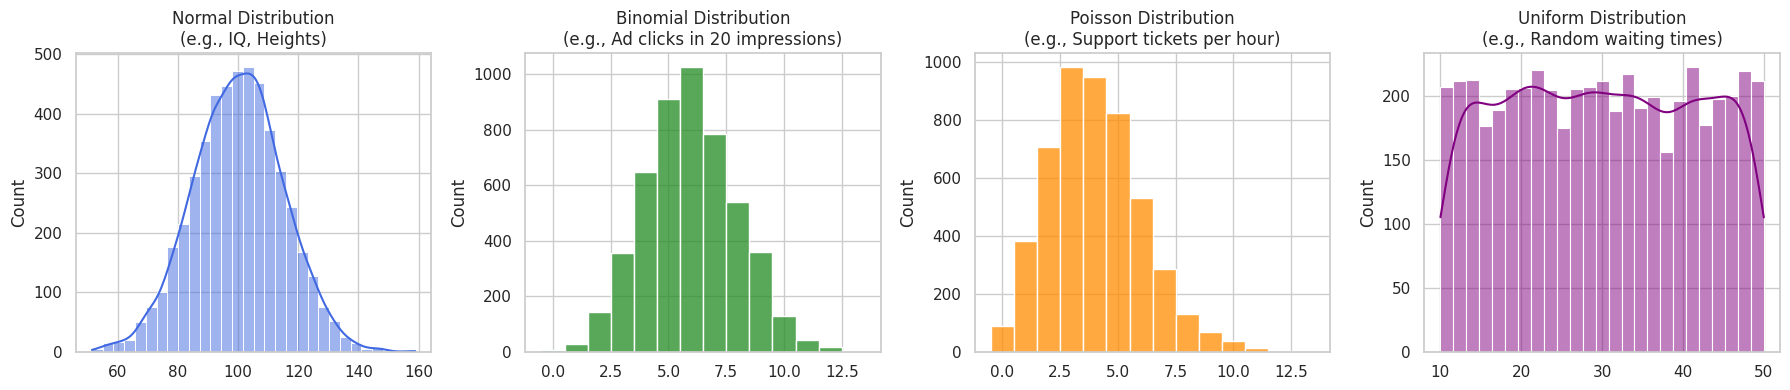

In [20]:
np.random.seed(42)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Normal (μ=100, σ=15)
norm_data = np.random.normal(loc=100, scale=15, size=5000)
sns.histplot(norm_data, kde=True, ax=axes[0], color='royalblue', bins=30)
axes[0].set_title("Normal Distribution\n(e.g., IQ, Heights)")

# Binomial (n=20 trials, p=0.3 success rate)
binom_data = np.random.binomial(n=20, p=0.3, size=5000)
sns.histplot(binom_data, discrete=True, ax=axes[1], color='forestgreen')
axes[1].set_title("Binomial Distribution\n(e.g., Ad clicks in 20 impressions)")

# Poisson (λ=4 average events per hour)
poisson_data = np.random.poisson(lam=4, size=5000)
sns.histplot(poisson_data, discrete=True, ax=axes[2], color='darkorange')
axes[2].set_title("Poisson Distribution\n(e.g., Support tickets per hour)")

# Uniform (Continuous between 10 and 50)
uniform_data = np.random.uniform(low=10, high=50, size=5000)
sns.histplot(uniform_data, kde=True, ax=axes[3], color='purple', bins=25)
axes[3].set_title("Uniform Distribution\n(e.g., Random waiting times)")

plt.tight_layout()
plt.show()

### SECTION 3: SAMPLING TECHNIQUES & SAMPLING BIAS

1. Simple Random Sampling: Every individual has an equal probability of selection.
2. Stratified Sampling: Divide population into strata (e.g., gender, tier), sample proportionally from each.
3. Cluster Sampling: Divide into natural clusters (e.g., store locations), sample entire clusters.
4. Systematic Sampling: Select every k-th individual from an ordered list.

SAMPLING BIAS:
- Selection Bias: Systematic exclusion of certain groups (e.g., online-only surveys exclude non-users).
- Survivorship Bias: Concentrating on entities that passed a hurdle (e.g., analyzing only successful startups).

In [21]:
pop_df = pd.DataFrame({
    'Customer_ID': range(1, 1001),
    'Tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=1000, p=[0.60, 0.30, 0.10]),
    'Spend': np.random.exponential(scale=100, size=1000)
})

# A. Simple Random Sample (n = 100)
srs_sample = pop_df.sample(n=100, random_state=42)

# B. Stratified Sample (maintains exact population proportions: 60% Bronze, 30% Silver, 10% Gold)
strat_sample = pop_df.groupby('Tier', group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
)

print("--- Population Tier Breakdown ---")
print((pop_df['Tier'].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

print("\n--- Stratified Sample Tier Breakdown ---")
print((strat_sample['Tier'].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

--- Population Tier Breakdown ---
Tier
Bronze    58.8%
Silver    33.0%
Gold       8.2%
Name: proportion, dtype: object

--- Stratified Sample Tier Breakdown ---
Tier
Bronze    59.0%
Silver    33.0%
Gold       8.0%
Name: proportion, dtype: object


/tmp/ipykernel_976/1954342919.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat_sample = pop_df.groupby('Tier', group_keys=False).apply(


### SECTION 4: LIVE DEMO — CENTRAL LIMIT THEOREM (CLT) SIMULATION

CLT Principle:
- Regardless of the underlying population distribution (skewed, uniform, bimodal),
- the sampling distribution of the sample mean (x̄) converges to a Normal Distribution as sample size (n) increases (typically n ≥ 30).

- Sampling Distribution Mean: ` μ_x̄ = μ`
- Standard Error: `SE = σ / √n`

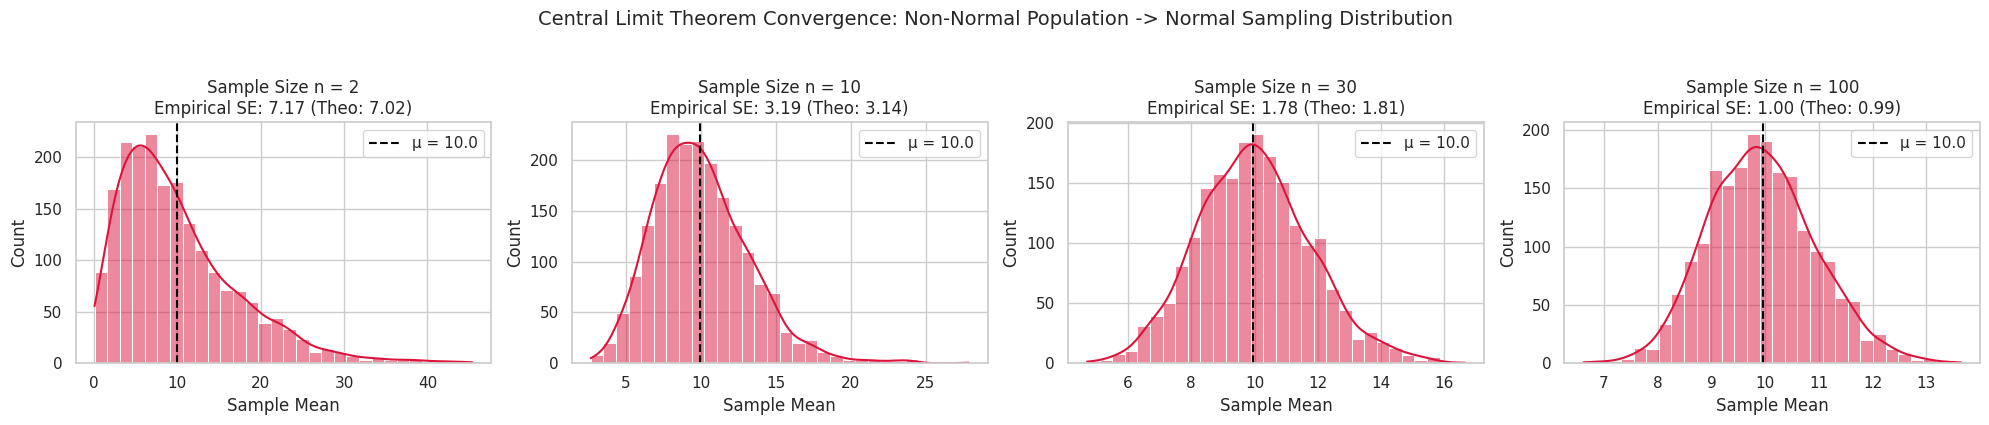

In [22]:
np.random.seed(42)

# Highly skewed Exponential Population (e.g., Customer Support Hold Times)
population = np.random.exponential(scale=10, size=100_000)
pop_mean = np.mean(population)
pop_std = np.std(population)

sample_sizes = [2, 10, 30, 100]
n_simulations = 2000

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, n in enumerate(sample_sizes):
    # Draw 2,000 independent samples of size n and compute their means
    sample_means = [np.mean(np.random.choice(population, size=n, replace=False)) for _ in range(n_simulations)]

    theoretical_se = pop_std / np.sqrt(n)
    empirical_se = np.std(sample_means)

    sns.histplot(sample_means, kde=True, ax=axes[idx], color='crimson', bins=30)
    axes[idx].axvline(pop_mean, color='black', linestyle='--', label=f'μ = {pop_mean:.1f}')
    axes[idx].set_title(f"Sample Size n = {n}\nEmpirical SE: {empirical_se:.2f} (Theo: {theoretical_se:.2f})")
    axes[idx].set_xlabel("Sample Mean")
    axes[idx].legend()

plt.suptitle("Central Limit Theorem Convergence: Non-Normal Population -> Normal Sampling Distribution", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### SECTION 5: STANDARD ERROR & CONFIDENCE INTERVALS (CI)

1. **Standard Error (SE):** Standard deviation of the sampling distribution: `SE = s / √n`
- 95% Confidence Interval Formula:  `CI = x̄ ± (t_critical * SE)`

2. **PRECISE INTERPRETATION OF A 95% CONFIDENCE INTERVAL:**
3. **Correct:** "If we repeat this experiment 100 times and construct a 95% CI each time, approximately 95 of those intervals will contain the true population mean μ."  
4. **Incorrect:** "There is a 95% probability that the true population mean lies inside THIS specific fixed interval."(In frequentist statistics, μ is fixed; the interval is what varies between samples).

In [23]:
sample_revenue = np.array([120, 135, 128, 142, 150, 115, 130, 138, 145, 125, 132, 140])
n_rev = len(sample_revenue)
mean_rev = np.mean(sample_revenue)
std_rev = np.std(sample_revenue, ddof=1)
se_rev = std_rev / np.sqrt(n_rev)

# Compute 95% CI using Student's t-distribution (dof = n - 1)
confidence = 0.95
t_crit = stats.t.ppf((1 + confidence) / 2, df=n_rev - 1)
margin_of_error = t_crit * se_rev
ci_lower = mean_rev - margin_of_error
ci_upper = mean_rev + margin_of_error

print("=== 95% CONFIDENCE INTERVAL ===")
print(f"Sample Mean (x̄):       ${mean_rev:.2f}")
print(f"Standard Error (SE):   ${se_rev:.2f}")
print(f"Margin of Error (ME):  ${margin_of_error:.2f}")
print(f"95% Confidence Interval: [${ci_lower:.2f}, ${ci_upper:.2f}]")

=== 95% CONFIDENCE INTERVAL ===
Sample Mean (x̄):       $133.33
Standard Error (SE):   $2.99
Margin of Error (ME):  $6.59
95% Confidence Interval: [$126.75, $139.92]


### SECTION 6: HYPOTHESIS TESTING FRAMEWORK & DECISION MATRIX

1. Key Components:
- H0 (Null Hypothesis): Default status quo; "No effect", "No difference".
- H1 (Alternative Hypothesis): The research claim; "There is a significant effect".
- Significance Level (α): Probability of rejecting H0 when H0 is actually true (Type I Error). Default = 0.05.  

- p-value: P(Observing data as extreme or more extreme | H0 is TRUE).
   * If p-value ≤ α -> Reject H0 (Statistically Significant).
   * If p-value > α  -> Fail to Reject H0 (Insufficient evidence).

2. DECISION ERROR MATRIX:

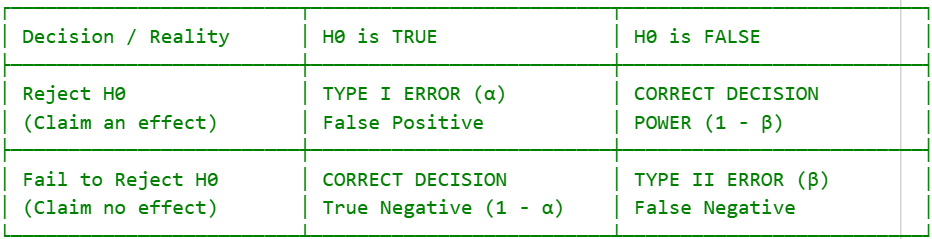

### SECTION 7: WHICH STATISTICAL TEST TO USE?

1. One-Sample t-test: Compare 1 sample mean against a known constant scalar benchmark.
2. Two-Sample Independent t-test (Welch's): Compare means of 2 independent groups (A vs B).
3. Paired t-test: Compare means from the same subjects measured twice (Before vs After).
4. One-Way ANOVA: Compare means across 3 or more continuous groups.
5. Chi-Square (χ²) Test of Independence: Test relationship between 2 categorical variables.

In [24]:
# --- Example A: Two-Sample Welch's t-test ---
group_A = np.random.normal(loc=50, scale=8, size=40)
group_B = np.random.normal(loc=55, scale=9, size=40)
t_stat, p_val_t = stats.ttest_ind(group_A, group_B, equal_var=False) # Welch's t-test
print(f"Two-Sample t-test:    t-stat = {t_stat:.3f}, p-value = {p_val_t:.4f}")

# --- Example B: One-Way ANOVA (3 Pricing Tiers) ---
tier_1 = [25, 30, 28, 35, 29]
tier_2 = [40, 45, 38, 42, 44]
tier_3 = [20, 22, 25, 19, 24]
f_stat, p_val_anova = stats.f_oneway(tier_1, tier_2, tier_3)
print(f"One-Way ANOVA:        F-stat = {f_stat:.3f}, p-value = {p_val_anova:.4f}")

# --- Example C: Chi-Square Test of Independence ---
# Contingency Table: Device (Mobile/Desktop) vs Converted (Yes/No)
contingency = np.array([
    [120, 380],  # Mobile:  120 Converted, 380 Not Converted
    [180, 320]   # Desktop: 180 Converted, 320 Not Converted
])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-Square Test:      χ²-stat = {chi2_stat:.3f}, p-value = {p_val_chi2:.4f}")

Two-Sample t-test:    t-stat = -3.775, p-value = 0.0003
One-Way ANOVA:        F-stat = 53.621, p-value = 0.0000
Chi-Square Test:      χ²-stat = 16.576, p-value = 0.0000


### SECTION 8: A/B TESTING METHODOLOGY & SAMPLE SIZE INTUITION

**Components of A/B Experimentation:**
1. Baseline Conversion Rate (e.g., current checkout rate = 10%).
2. Minimum Detectable Effect (MDE): Smallest meaningful lift to detect (e.g., relative +15% -> 11.5%).
3. Significance Level (α = 0.05): Tolerable false positive rate.
4. Statistical Power (1 - β = 0.80): Probability of detecting an effect if one truly exists.

RULE OF THUMB: Detecting smaller lifts requires quadratically larger sample sizes!

In [25]:
def rough_ab_sample_size(p1, relative_lift, alpha=0.05, power=0.80):
    """Calculates required sample size per variant for binomial conversion test."""
    p2 = p1 * (1 + relative_lift)
    p_pool = (p1 + p2) / 2
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n = (2 * p_pool * (1 - p_pool) * (z_alpha + z_beta)**2) / ((p2 - p1)**2)
    return int(np.ceil(n))

req_n = rough_ab_sample_size(p1=0.10, relative_lift=0.15) # 10% baseline, 15% lift
print(f"Required Sample Size per Variant (15% lift on 10% base): ~{req_n:,} users")

Required Sample Size per Variant (15% lift on 10% base): ~6,694 users


### SECTION 9: STUDENT LAB ASSIGNMENT (A/B EXPERIMENT EVALUATION)

LAB INSTRUCTIONS:
An e-commerce company tested a new checkout page design (Variant B) against the current design (Variant A).
They collected transaction order values ($) for both variants.

YOUR TASKS:
1. State the Null (H0) and Alternative (H1) hypotheses for comparing average order value.
2. Conduct a Two-Sample Welch's t-test (alpha = 0.05).
3. Compute the sample means and 95% confidence intervals for both variants.
4. Synthesize your statistical findings into a one-paragraph business recommendation for the executive team.


### Task 1: State Hypotheses

*   **Null Hypothesis (H0):** There is no significant difference in the average order value between Variant A (current design) and Variant B (new design). Mathematically, μ_A = μ_B.
*   **Alternative Hypothesis (H1):** There is a significant difference in the average order value between Variant A and Variant B. Mathematically, μ_A ≠ μ_B.

In [27]:
# Task 2: Conduct a Two-Sample Welch's t-test (alpha = 0.05)
# Task 3: Compute the sample means and 95% confidence intervals for both variants.

alpha = 0.05

# Perform Welch's t-test
t_stat, p_val = stats.ttest_ind(ab_experiment_df['Variant_A'], ab_experiment_df['Variant_B'], equal_var=False)

print("\n--- Welch's t-test Results ---")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.4f}")

if p_val < alpha:
    print(f"Conclusion: Reject H0. There is a statistically significant difference (p < {alpha}).")
else:
    print(f"Conclusion: Fail to Reject H0. There is no statistically significant difference (p > {alpha}).")

# Compute sample means
mean_a = ab_experiment_df['Variant_A'].mean()
mean_b = ab_experiment_df['Variant_B'].mean()

# Compute 95% Confidence Intervals
def calculate_ci(data, confidence=0.95):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data) # Standard Error of the Mean
    h = std_err * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean - h, mean + h

ci_a_lower, ci_a_upper = calculate_ci(ab_experiment_df['Variant_A'])
ci_b_lower, ci_b_upper = calculate_ci(ab_experiment_df['Variant_B'])

print("\n--- Sample Statistics and 95% Confidence Intervals ---")
print(f"Variant A Mean: {mean_a:.2f}")
print(f"Variant A 95% CI: [{ci_a_lower:.2f}, {ci_a_upper:.2f}]")
print(f"Variant B Mean: {mean_b:.2f}")
print(f"Variant B 95% CI: [{ci_b_lower:.2f}, {ci_b_upper:.2f}]")


--- Welch's t-test Results ---
t-statistic: -2.572
p-value: 0.0106
Conclusion: Reject H0. There is a statistically significant difference (p < 0.05).

--- Sample Statistics and 95% Confidence Intervals ---
Variant A Mean: 72.62
Variant A 95% CI: [70.34, 74.90]
Variant B Mean: 77.12
Variant B 95% CI: [74.52, 79.72]


### Task 4: Business Recommendation

Based on the A/B test results, the new checkout page design (Variant B) shows a statistically significant increase in the average order value (p-value = **0.0106**, which is less than the significance level of 0.05). Variant B's average order value was **$77.12** (95% CI: [**$74.52**, **$79.72**]), compared to Variant A's average of **$72.62** (95% CI: [**$70.34**, **$74.90**]). This indicates that customers tend to spend more when exposed to the new design. Therefore, I recommend implementing Variant B as the default checkout page, as it is projected to positively impact overall revenue per transaction.

In [36]:
# Generate Experiment Data
np.random.seed(888)
ab_experiment_df = pd.DataFrame({
    'Variant_A': np.random.normal(loc=72.50, scale=14.0, size=150),
    'Variant_B': np.random.normal(loc=77.20, scale=15.5, size=150)
})

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR ANALYSIS BELOW) - Given in the above cells
# ------------------------------------------------------------------------------

#**LAB BUSINESS DATASET**

In [37]:
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


### STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING

BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:

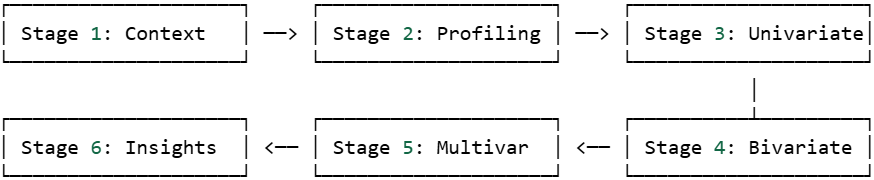

In [38]:
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [39]:
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT

print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---")
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))

print("\n--- 4. Categorical Cardinality & Balance ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_976/596769692.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])


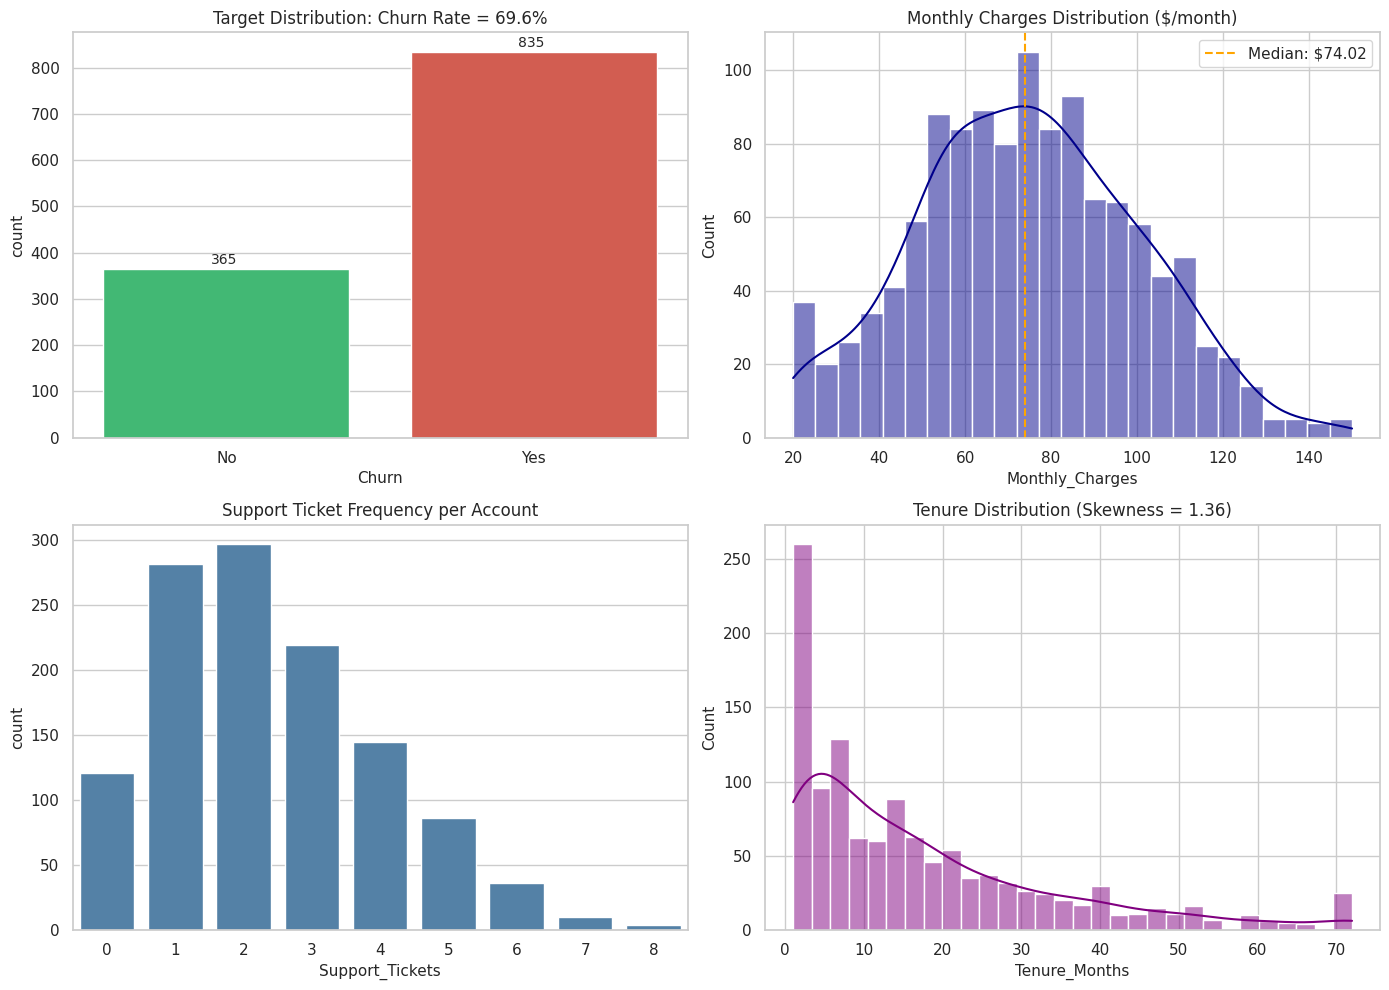

In [40]:
# STAGE 3: UNIVARIATE ANALYSIS
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30)
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()

# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

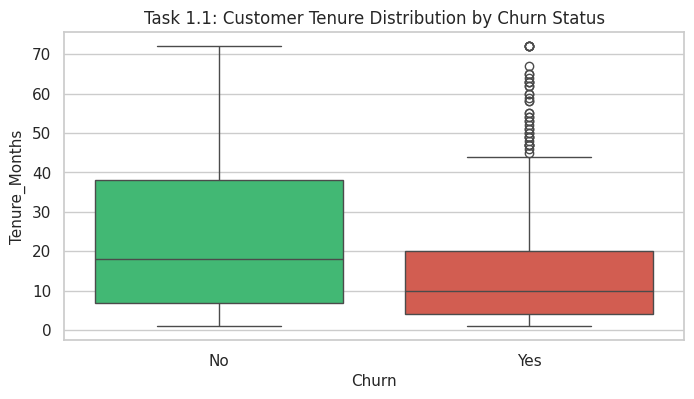


--- Tenure Statistics by Churn Status ---


,Median,Q1,Q3,IQR
Churn,,,,
No,18.0,7.0,38.0,31.0
Yes,10.0,4.0,20.0,16.0


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# TASK 1: BIVARIATE ANALYSIS (3 Sub-Tasks)

# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# Task: Create a grouped boxplot or violin plot of `Tenure_Months` grouped by `Churn`.
#       Compute and display the median and IQR of tenure for both groups.

plt.figure(figsize=(8, 4))

# TODO: Write your plotting code below (e.g., sns.boxplot or sns.violinplot)
sns.boxplot(data=df, x='Churn', y='Tenure_Months', hue='Churn', palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, legend=False)

plt.title("Task 1.1: Customer Tenure Distribution by Churn Status")
plt.show()

# TODO: Compute and print the Median and IQR of Tenure for Churned vs Retained customers
tenure_stats = df.groupby('Churn')['Tenure_Months'].agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
tenure_stats.columns = ['Median', 'Q1', 'Q3']
tenure_stats['IQR'] = tenure_stats['Q3'] - tenure_stats['Q1']

print("\n--- Tenure Statistics by Churn Status ---")
display(tenure_stats.round(2))

--- Churn Rates across Contract & Tech Support ---


Churn                           No    Yes
Contract_Type  Tech_Support              
Month-to-Month No            13.86  86.14
               No internet   15.18  84.82
               Yes           15.29  84.71
One-Year       No            31.88  68.12
               No internet   40.48  59.52
               Yes           48.12  51.88
Two-Year       No            63.55  36.45
               No internet   54.05  45.95
               Yes           65.12  34.88

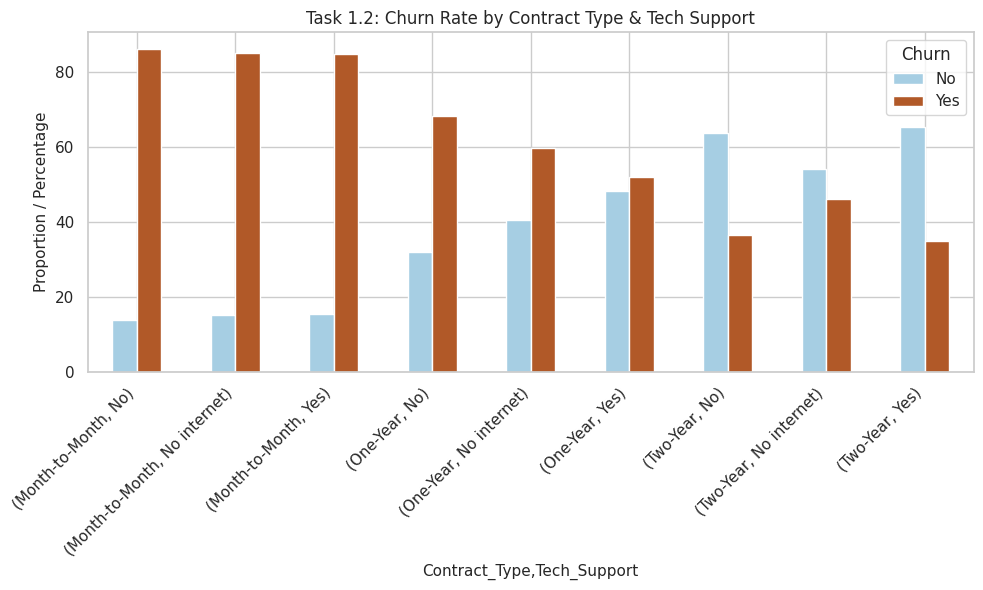

In [43]:
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# Task: Generate a normalized crosstab (percentages) showing the churn rate across
#       different `Contract_Type` and `Tech_Support` combinations.
#       Plot as a stacked or grouped bar chart.

# TODO: Create the crosstab
contract_tech_churn = pd.crosstab(
    [df['Contract_Type'], df['Tech_Support']],
    df['Churn'],
    normalize='index' # Normalize by row to get churn rate within each group
).mul(100).round(2) # Convert to percentage

print("--- Churn Rates across Contract & Tech Support ---")
display(contract_tech_churn)

# TODO: Plot the crosstab as a bar chart
contract_tech_churn.plot(kind='bar', figsize=(10, 6), stacked=False, cmap='Paired')
plt.title("Task 1.2: Churn Rate by Contract Type & Tech Support")
plt.ylabel("Proportion / Percentage")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

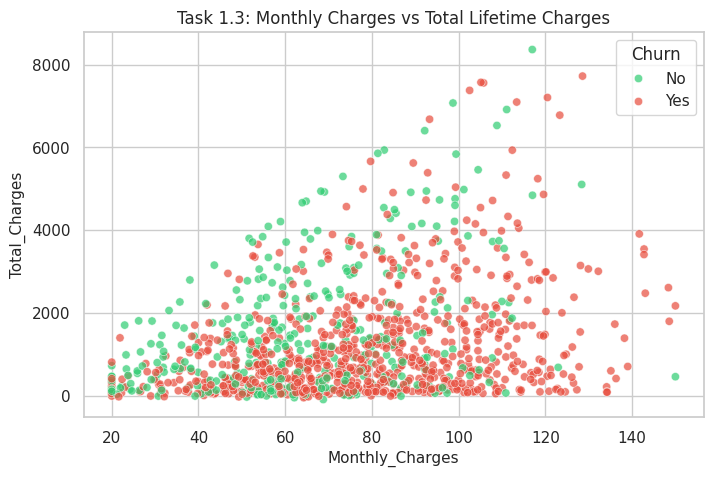


--- Correlation between Monthly_Charges and Total_Charges ---
Pearson Correlation: 0.300 | Spearman Correlation: 0.269


In [44]:
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# Task: Generate a scatter plot comparing `Monthly_Charges` vs `Total_Charges`
#       colored by `Churn` status. Calculate the Pearson and Spearman correlations.

plt.figure(figsize=(8, 5))

# TODO: Write your scatterplot code below (sns.scatterplot with hue='Churn')
sns.scatterplot(data=df, x='Monthly_Charges', y='Total_Charges', hue='Churn', palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, alpha=0.7)

plt.title("Task 1.3: Monthly Charges vs Total Lifetime Charges")
plt.show()

# TODO: Compute and print Pearson and Spearman correlation between Monthly_Charges and Total_Charges
# Drop rows with NaN in Total_Charges for correlation calculation
df_corr = df.dropna(subset=['Total_Charges'])
pearson_corr = df_corr['Monthly_Charges'].corr(df_corr['Total_Charges'], method='pearson')
spearman_corr = df_corr['Monthly_Charges'].corr(df_corr['Total_Charges'], method='spearman')

print("\n--- Correlation between Monthly_Charges and Total_Charges ---")
print(f"Pearson Correlation: {pearson_corr:.3f} | Spearman Correlation: {spearman_corr:.3f}")

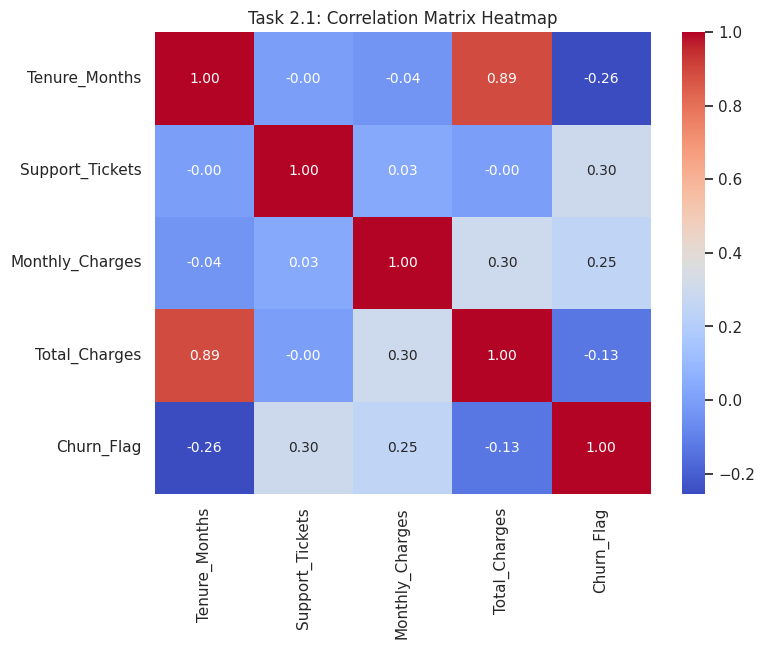

In [45]:
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION

# 2.1 CORRELATION HEATMAP
# Task: Encode 'Churn' as 1 (Yes) and 0 (No). Select all numeric columns and
#       plot an annotated correlation heatmap (sns.heatmap) using a divergent palette.

df_numeric = df.copy()

# TODO: Create binary numeric column 'Churn_Flag' (1 for 'Yes', 0 for 'No')
df_numeric['Churn_Flag'] = df_numeric['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numeric columns for correlation matrix
numeric_cols = df_numeric.select_dtypes(include=np.number).columns

# TODO: Calculate correlation matrix and display heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_numeric[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Task 2.1: Correlation Matrix Heatmap")
plt.show()

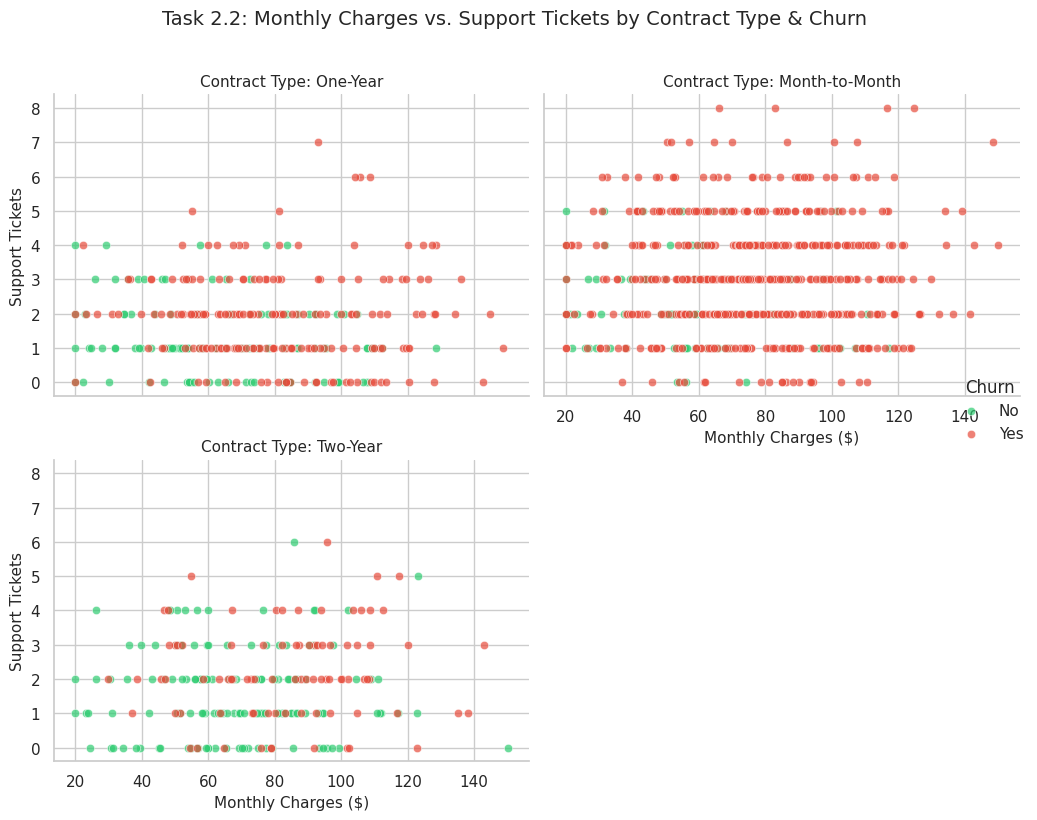

In [46]:
# 2.2 MULTI-DIMENSIONAL SEGMENTATION (FacetGrid / Subplots)
# Task: Plot `Monthly_Charges` vs `Support_Tickets` using FacetGrid segmented
#       by `Contract_Type` with `hue='Churn'`.

# TODO: Build and map a sns.FacetGrid
g = sns.FacetGrid(df, col='Contract_Type', hue='Churn', col_wrap=2, height=4, aspect=1.2, palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
g.map(sns.scatterplot, 'Monthly_Charges', 'Support_Tickets', alpha=0.7)
g.add_legend()
g.set_axis_labels("Monthly Charges ($)", "Support Tickets")
g.set_titles("Contract Type: {col_name}")
plt.suptitle("Task 2.2: Monthly Charges vs. Support Tickets by Contract Type & Churn", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
# TASK 3: MISSING VALUE & OUTLIER TREATMENT (EDA CONTEXT)


# 3.1 Missing Value Treatment in Total_Charges
# Context: Total_Charges has 15 missing values.
# Task: Impute missing Total_Charges using the formula (Tenure_Months * Monthly_Charges).
#       Explain in a comment why this is superior to simple mean/median imputation.


# TODO: Impute Total_Charges using calculated tenure * monthly charges
df['Total_Charges'] = df['Total_Charges'].fillna(df['Tenure_Months'] * df['Monthly_Charges'])

# Explanation: Imputing with (Tenure_Months * Monthly_Charges) is superior to simple mean/median imputation
# because it leverages the logical relationship between these variables. Total_Charges should ideally
# be the sum of monthly charges over tenure. This method retains the intrinsic structure of the data,
# preventing distortions that could arise from using a generic central tendency measure, especially if
# there's a strong correlation or causal link between the features.
print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")

Missing values remaining in Total_Charges: 0


In [48]:
# 3.2 Outlier Investigation: Support Tickets
# Task: Identify accounts where Support_Tickets > (Q3 + 1.5 * IQR).
#       Determine the churn rate among these high-ticket outliers.

# TODO: Calculate IQR fences for Support_Tickets
q1_tix = df['Support_Tickets'].quantile(0.25)
q3_tix = df['Support_Tickets'].quantile(0.75)
iqr_tix = q3_tix - q1_tix
upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df['Support_Tickets'] > upper_fence]
print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")

if not outlier_accounts.empty:
    churn_rate_outliers = (outlier_accounts['Churn'] == 'Yes').mean() * 100
    print(f"Churn Rate in Outlier Accounts: {churn_rate_outliers:.2f}%")
else:
    print("No outliers found for Support_Tickets based on the 1.5*IQR rule.")

Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [49]:
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING

# Task: Engineer at least TWO new features that capture behavioral or financial risk.

# Feature Idea 1: `Ticket_Velocity` = Support_Tickets / (Tenure_Months + 1)
#   (Hypothesis: High support requests in early tenure signals severe onboarding friction)
#
# Feature Idea 2: `High_Risk_Flag` = 1 if (Contract == 'Month-to-Month' and Tech_Support == 'No') else 0
#   (Hypothesis: Unassisted flexible contracts have compounded churn risk)


# TODO: Create Feature 1
df['Ticket_Velocity'] = df['Support_Tickets'] / (df['Tenure_Months'] + 1)

# TODO: Create Feature 2
df['High_Risk_Flag'] = ((df['Contract_Type'] == 'Month-to-Month') & (df['Tech_Support'] == 'No')).astype(int)

# Validate predictive utility: Compare churn rates across your engineered features
print("--- Churn Rate Comparison for Engineered Features ---")
display(df.groupby('High_Risk_Flag')['Churn'].value_counts(normalize=True).unstack() * 100)
display(df.groupby('Churn')['Ticket_Velocity'].describe())

--- Churn Rate Comparison for Engineered Features ---


Churn,No,Yes
High_Risk_Flag,,
0,36.008919,63.991081
1,13.861386,86.138614


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.168059,0.276427,0.0,0.025000,0.065217,0.181818,2.0
Yes,835.0,0.415001,0.534765,0.0,0.090909,0.200000,0.500000,3.0


### 📊 Strategic Insight 1: High-Risk Customer Identification
*   **Claim:** Customers classified with a `High_Risk_Flag` (Month-to-Month contracts without Tech Support) exhibit a significantly elevated churn rate, indicating a critical segment for targeted intervention.
*   **Evidence:** Customers with `High_Risk_Flag = 1` show a churn rate of **86.14%**, substantially higher than the **63.99%** churn rate for customers with `High_Risk_Flag = 0`.
*   **Business Action:** Implement a proactive retention program for customers identified by the `High_Risk_Flag`. This could include offering personalized tech support packages, incentives for upgrading to longer-term contracts, or early intervention by customer success managers to address potential pain points.

---

### 📊 Strategic Insight 2: Early Warning for Customer Frustration (`Ticket_Velocity`)
*   **Claim:** A higher `Ticket_Velocity` (support tickets relative to tenure) serves as an early indicator of customer frustration and is strongly associated with increased churn risk, especially in early tenure.
*   **Evidence:** Churned customers have a mean `Ticket_Velocity` of **0.415** (median **0.200**), which is more than double that of retained customers (mean **0.168**, median **0.065**).
*   **Business Action:** Establish an alert system that flags customers with a rapidly increasing `Ticket_Velocity`, particularly during their initial months. Customer Success teams should use these alerts to initiate immediate outreach, offer dedicated support, and gather feedback to mitigate issues before they escalate to churn.

---

### 📊 Strategic Insight 3: [Short Descriptive Title]
*   **Claim:** [State a concise, definitive finding about customer behavior or churn drivers]
*   **Evidence:** [Provide exact metrics: sample sizes, percentages, median/IQR differences, correlations, or p-values]
*   **Business Action:** [Propose an actionable, practical business initiative or intervention]

---

### 📊 Strategic Insight 4: [Short Descriptive Title]
*   **Claim:** [State a concise, definitive finding about customer behavior or churn drivers]
*   **Evidence:** [Provide exact metrics: sample sizes, percentages, median/IQR differences, correlations, or p-values]
*   **Business Action:** [Propose an actionable, practical business initiative or intervention]

---

### 📊 Strategic Insight 5: [Short Descriptive Title]
*   **Claim:** [State a concise, definitive finding about customer behavior or churn drivers]
*   **Evidence:** [Provide exact metrics: sample sizes, percentages, median/IQR differences, correlations, or p-values]
*   **Business Action:** [Propose an actionable, practical business initiative or intervention]

### TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)

COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
